In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("olist_orders_dataset.csv")

display(orders.head(2))

# Drop undelivered orders
clean_orders = orders[orders['order_status'] == 'delivered'].copy()

# Convert into datetime
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    clean_orders[col] = pd.to_datetime(clean_orders[col])

# Drop NaN
clean_orders = clean_orders.dropna(subset=['order_purchase_timestamp', 'order_delivered_customer_date'])

# Convert into days
clean_orders['actual_lead_time_days'] = (clean_orders['order_delivered_customer_date'] - clean_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
clean_orders['estimated_lead_time_days'] = (clean_orders['order_estimated_delivery_date'] - clean_orders['order_purchase_timestamp']).dt.total_seconds() / 86400

# 1 is delayed，0 is on time
clean_orders['is_delayed'] = np.where(clean_orders['order_delivered_customer_date'] > clean_orders['order_estimated_delivery_date'], 1, 0)

display(clean_orders[['order_id', 'actual_lead_time_days', 'estimated_lead_time_days', 'is_delayed']].head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


,order_id,actual_lead_time_days,estimated_lead_time_days,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0


In [3]:
products = pd.read_csv("olist_products_dataset.csv")

display(products[['product_id', 'product_length_cm', 'product_height_cm', 'product_width_cm']].head(2))

# Compute CBM of every SKU
# CBM = (length/100) * (width/100) * (height/100)
# Use median to fill the missing data
for col in ['product_length_cm', 'product_height_cm', 'product_width_cm']:
    median_val = products[col].median()
    products[col] = products[col].fillna(median_val)

products['product_length_m'] = products['product_length_cm'] / 100.0
products['product_height_m'] = products['product_height_cm'] / 100.0
products['product_width_m'] = products['product_width_cm'] / 100.0
products['single_sku_cbm'] = products['product_length_m'] * products['product_height_m'] * products['product_width_m']

display(products[['product_id', 'single_sku_cbm']].head())

,product_id,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,30.0,18.0,20.0


,product_id,single_sku_cbm
0,1e9e8ef04dbcff4541ed26657ea517e5,0.002240
1,3aa071139cb16b67ca9e5dea641aaa2f,0.010800
2,96bd76ec8810374ed1b65e291975717f,0.002430
3,cef67bcfe19066a932b7673e239eb23d,0.002704
4,9dc1a7de274444849c219cff195d0b71,0.004420


In [3]:
order_items = pd.read_csv("olist_order_items_dataset.csv")

# Merge order_items, product_id, single_sku_cbm
items_with_cbm = pd.merge(order_items, products[['product_id', 'single_sku_cbm']], on='product_id', how='left')

# Merge items_with_cbm with clean_orders
final_supply_chain_df = pd.merge(clean_orders, items_with_cbm[['order_id', 'product_id', 'single_sku_cbm']], on='order_id', how='inner')

display(final_supply_chain_df[['order_id', 'actual_lead_time_days', 'product_id', 'single_sku_cbm']].head())


恭喜！三表合一成功，最终供应链建模宽表诞生：


,order_id,actual_lead_time_days,product_id,single_sku_cbm
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,87285b34884572647811a353c7ac498a,0.001976
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,595fac2a385ac33a80bd5114aec74eb8,0.004693
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,aa4383b373c6aca5d8797843e5594415,0.009576
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,d0b61bfb1de832b15ba9d266ca96e5b0,0.006000
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,65266b2da20d04dbe00c5c2d3bb7859e,0.011475


📊 数理统计拟合结果：
对数空间均值 (Mu, μ): 2.3004
对数空间标准差 (Sigma, σ): 0.6792
这意味着该供应链的平均交期大约为 12.57 天


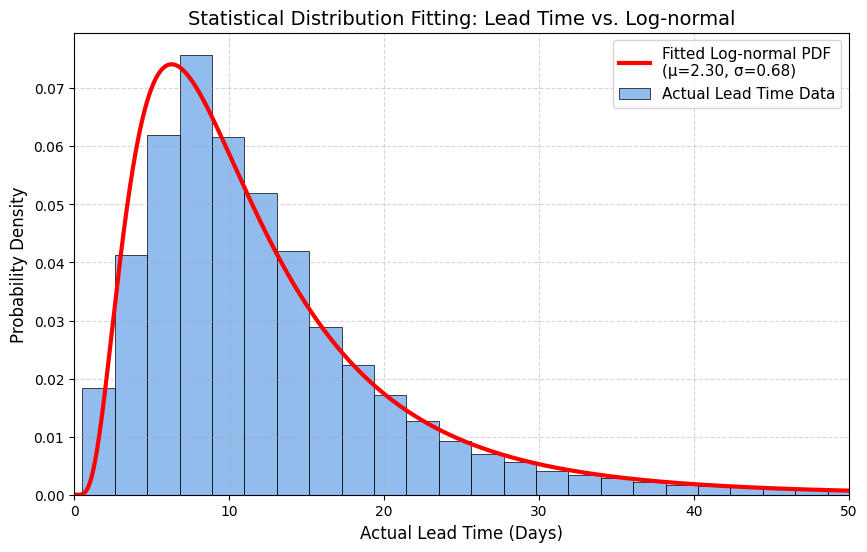

In [4]:
import scipy.stats as stats

# Extract lead time data
lead_time_data = final_supply_chain_df['actual_lead_time_days'].dropna()

# 
# Use lognorm fit model from scipy.stats (shape parameter(s), location parameter(loc), scale parameter(scale))
s, loc, scale = stats.lognorm.fit(lead_time_data, floc=0) # minimum lead time is 0

# Compute mean(mu) and standard deviation(sigma) of lognorm
mu = np.log(scale)
sigma = s

print(f"Log Mean (Mu, μ): {mu:.4f}")
print(f"Log Standard Deviation (Sigma, σ): {sigma:.4f}")
print(f"Mean lead time is {np.exp(mu + (sigma**2)/2):.2f} days")

# Visualization: Actual VS Fitted
plt.figure(figsize=(10, 6))

# Plot histogram of actual lead time data
sns.histplot(lead_time_data, bins=100, stat='density', alpha=0.6, color='#4A90E2', label='Actual Lead Time Data')

# Plot fitted lognorm PDF
x = np.linspace(0, 50, 1000)
pdf = stats.lognorm.pdf(x, s, loc, scale)
plt.plot(x, pdf, 'r-', lw=3, label=f'Fitted Log-normal PDF\n(μ={mu:.2f}, σ={sigma:.2f})')

plt.xlim(0, 50)
plt.title('Statistical Distribution Fitting: Lead Time vs. Log-normal', fontsize=14)
plt.xlabel('Actual Lead Time (Days)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

In [5]:
from scipy import stats  

# 1. Clean the data
valid_orders = clean_orders[clean_orders['actual_lead_time_days'] > 0].copy()

# 2. Compute actual mean and sd of lead time
mean_lead_time_L = valid_orders['actual_lead_time_days'].mean()
std_lead_time_L = valid_orders['actual_lead_time_days'].std()

print(f"Daily Mean Demand: {mean_demand_D} ")
print(f"Mean Lead Time: {mean_lead_time_L:.2f} days, standard deviation: {std_lead_time_L:.2f}\n")

# 3. Define function of safety stock and reorder point
def calculate_safety_stock(service_level=0.95):
    # Use scipy compute z score of normal distribution
    z_score = stats.norm.ppf(service_level)
    
    # Use dynamic supply chain uncertainty formula
    combined_sigma = np.sqrt(mean_lead_time_L * (std_demand_D ** 2) + (mean_demand_D ** 2) * (std_lead_time_L ** 2))
    safety_stock = z_score * combined_sigma
    
    # Reorder Point, ROP = mean demand * mean lead time + safety score
    reorder_point = (mean_demand_D * mean_lead_time_L) + safety_stock
    
    return z_score, int(np.ceil(safety_stock)), int(np.ceil(reorder_point))

# 4. Compare 95% and 99%
for level in [0.95, 0.99]:
    z, ss, rop = calculate_safety_stock(level)
    print(f"When service level is {level*100}%  (Z = {z:.2f})：")
    print(f"   --> Safety Stock: {ss} ")
    print(f"   --> Reorder Point): {rop} ")
    print("-" * 60)

📦 基础数理输入：
日均需求量 (Mean Demand): 150 件, 标准差: 30
平均交期 (Mean Lead Time): 12.47 天, 标准差: 9.45

🎯 当服务水平(Service Level)卡在 95.0% 时 (Z = 1.64)：
   --> 英国海外仓需常备的【安全库存 (Safety Stock)】: 2337 件
   --> ERP系统触发报警的【再订货点 (Reorder Point)】: 4208 件
------------------------------------------------------------
🎯 当服务水平(Service Level)卡在 99.0% 时 (Z = 2.33)：
   --> 英国海外仓需常备的【安全库存 (Safety Stock)】: 3306 件
   --> ERP系统触发报警的【再订货点 (Reorder Point)】: 5177 件
------------------------------------------------------------


🚨 供应链压力测试结果（黑天鹅延误 12 天场景）：
   --> 修正后发生彻底断货（Stockout）的概率为: 49.24%


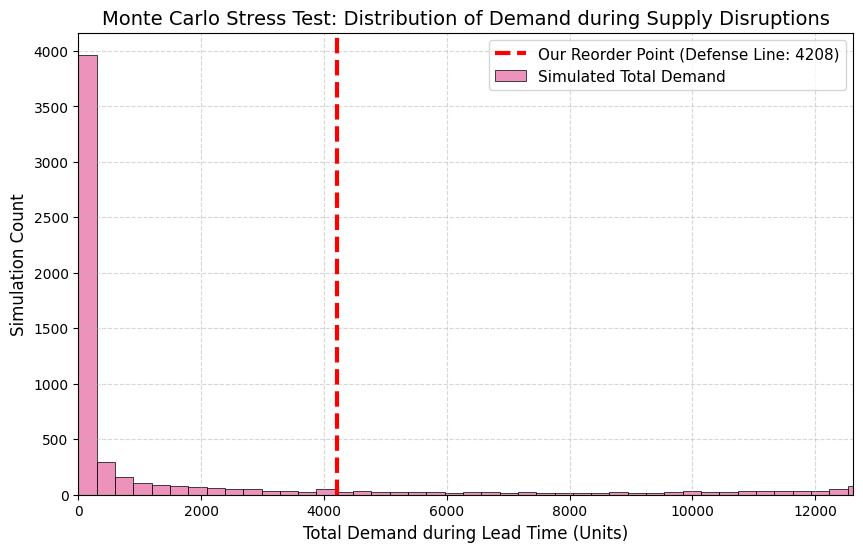

In [7]:
np.random.seed(42)

simulations = 10000
disrupted_mean_L = mean_lead_time_L + 12 
_, _, current_rop = calculate_safety_stock(service_level=0.95)

# 1. Get random lead time of lognormal
sim_lead_times = np.random.lognormal(mean=np.log(disrupted_mean_L), sigma=std_lead_time_L, size=simulations)

# Cut down the data over 120 days, avoid unshown on axis
sim_lead_times = np.clip(sim_lead_times, a_min=0, a_max=120)

# 2. Get random demand of normal
sim_demands = np.random.normal(loc=mean_demand_D, scale=std_demand_D, size=simulations)

# 3. Compute total demand during lead time
total_demand_during_lt = sim_lead_times * sim_demands

# 4. Compute probability of stock out
stockout_events = total_demand_during_lt > current_rop
stockout_probability = np.mean(stockout_events)

print(f"Outcome of supply chain pressure test：")
print(f"   Probability of Stockout: {stockout_probability * 100:.2f}%")

# Plot
plt.figure(figsize=(10, 6))

sns.histplot(total_demand_during_lt, bins=100, color='#E24A8D', alpha=0.6, label='Simulated Total Demand')
plt.axvline(current_rop, color='red', linestyle='--', linewidth=3, label=f'Our Reorder Point (Defense Line: {current_rop})')

# Make the fluctuations more distinct
plt.xlim(0, current_rop * 3)

plt.title('Monte Carlo Stress Test: Distribution of Demand during Supply Disruptions', fontsize=14)
plt.xlabel('Total Demand during Lead Time (Units)', fontsize=12)
plt.ylabel('Simulation Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()